# **Statistical Analysis**

In [ ]:
# Import the required libraries
import pandas as pd
from scipy import stats

# Load the CSVs directly
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")

In [ ]:
# Recreate the join in pandas: order_items -> orders (status), -> products (category)
df = (order_items
      .merge(orders[["order_id", "status"]], on="order_id", how="inner")
      .merge(products[["product_id", "category"]], on="product_id", how="inner"))

df["is_returned"] = (df["status"] == "Returned").astype(int)

In [ ]:
# Contingency table: category x returned/not
ct = pd.crosstab(df["category"], df["is_returned"])
ct.columns = ["Not Returned", "Returned"]
ct["return_rate_%"] = (100 * ct["Returned"] / (ct["Returned"] + ct["Not Returned"])).round(2)
print(ct.sort_values("return_rate_%", ascending=False))

                   Not Returned  Returned  return_rate_%
category                                                
Clothing                   1800       365          16.86
Electronics                1739       331          15.99
Home & Kitchen             1931       270          12.27
Beauty & Health            1611       220          12.02
Sports & Outdoors          1861       249          11.80
Toys & Games               2202       266          10.78
Office Supplies            1820       197           9.77
Books                      2453       247           9.15


In [ ]:
# Chi-Square test of independence
chi2, p, dof, expected = stats.chi2_contingency(ct[["Not Returned", "Returned"]].values)
print(f"\nChi-Square = {chi2:.2f}, dof = {dof}, p-value = {p:.2e}")
print("Reject H0 (return rate differs by category)" if p < 0.05
      else "Fail to reject H0 (no significant difference)")


Chi-Square = 111.19, dof = 7, p-value = 5.20e-21
Reject H0 (return rate differs by category)


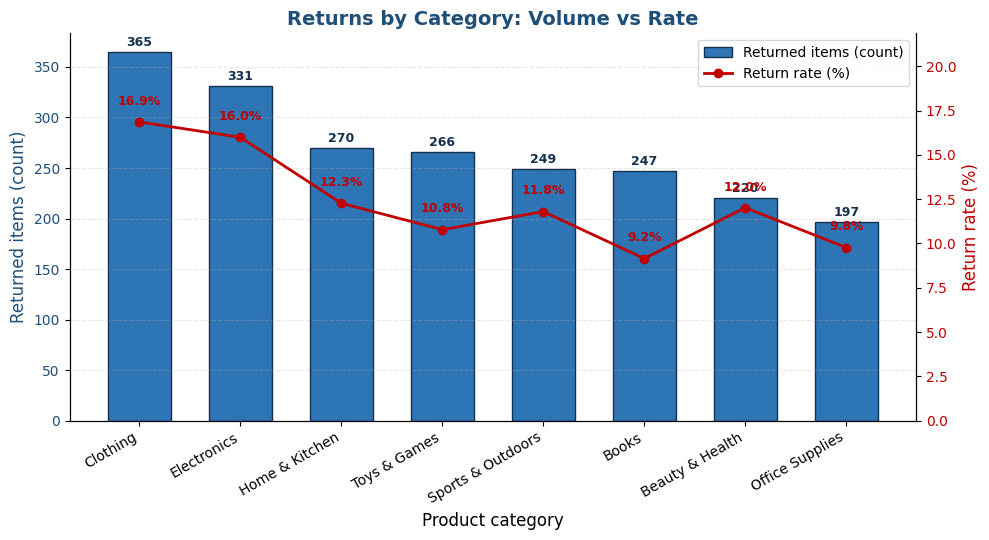

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Load and join (standalone) ---
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
products = pd.read_csv("products.csv")

df = (order_items
      .merge(orders[["order_id", "status"]], on="order_id", how="inner")
      .merge(products[["product_id", "category"]], on="product_id", how="inner"))
df["is_returned"] = (df["status"] == "Returned").astype(int)

# --- Per-category: total items, returned items, return rate ---
summary = df.groupby("category").agg(
    total_items=("is_returned", "size"),
    returned_items=("is_returned", "sum"),
).reset_index()
summary["return_rate"] = (100 * summary["returned_items"] / summary["total_items"]).round(2)
summary = summary.sort_values("returned_items", ascending=False)

# --- Combo chart: bars = returned-item COUNT, line = return RATE % ---
fig, ax1 = plt.subplots(figsize=(10, 5.5))

bars = ax1.bar(summary["category"], summary["returned_items"],
               color="#2E75B6", edgecolor="#15314F", linewidth=1.0,
               width=0.62, label="Returned items (count)")
ax1.set_ylabel("Returned items (count)", fontsize=12, color="#1F4E79")
ax1.tick_params(axis="y", labelcolor="#1F4E79")

# count labels on bars
for bar, val in zip(bars, summary["returned_items"]):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 3,
             f"{int(val)}", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#15314F")

# second axis: return rate %
ax2 = ax1.twinx()
ax2.plot(summary["category"], summary["return_rate"],
         color="#C00000", marker="o", linewidth=2, label="Return rate (%)")
ax2.set_ylabel("Return rate (%)", fontsize=12, color="#C00000")
ax2.tick_params(axis="y", labelcolor="#C00000")
ax2.set_ylim(0, summary["return_rate"].max() + 5)

for x, val in zip(summary["category"], summary["return_rate"]):
    ax2.text(x, val + 0.8, f"{val:.1f}%", ha="center", va="bottom",
             fontsize=9, color="#C00000", fontweight="bold")

ax1.set_title("Returns by Category: Volume vs Rate",
              fontsize=14, fontweight="bold", color="#1F4E79")
ax1.set_xlabel("Product category", fontsize=12)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.spines[["top"]].set_visible(False)
ax2.spines[["top"]].set_visible(False)
plt.setp(ax1.get_xticklabels(), rotation=30, ha="right")

# combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)

plt.tight_layout()
plt.savefig("returns_volume_vs_rate.png", dpi=150, bbox_inches="tight")
plt.show()